In [26]:
import pandas as pd
import numpy as np

In [41]:
travel_times_file = "/Users/sierrawelsch/CS4100_Final/Datasets/2022-Q1_HRTravelTimes.csv"
events_file = "/Users/sierrawelsch/CS4100_Final/Datasets/2022-01_HREvents.csv"
# expected arr/dep times for 2022-01-04
stop_times_file = "/Users/sierrawelsch/CS4100_Final/Datasets/20220103_stop_times.txt"
stop_times_file_2 = "/Users/sierrawelsch/CS4100_Final/Datasets/stop_times.txt"

In [45]:
events_df = pd.read_csv(events_file)
events_df.head()
events_df = events_df.drop(["vehicle_id", "vehicle_label", "direction_id"], axis = 1)
# events_df = events_df[events_df['service_date'] == '2022-01-04']
events_df['event_time_dt'] = pd.to_timedelta(events_df['event_time_sec'], unit='s').astype(str)
events_df

,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,event_time_dt
0,2022-01-01,Red,50346084,70094,50,ARR,1641037467,24267,0 days 06:44:27
1,2022-01-01,Red,50346084,70094,50,DEP,1641038236,25036,0 days 06:57:16
2,2022-01-01,Red,50346084,70092,60,ARR,1641038394,25194,0 days 06:59:54
3,2022-01-01,Red,50346084,70092,60,DEP,1641038435,25235,0 days 07:00:35
4,2022-01-01,Red,50346084,70090,70,ARR,1641038503,25303,0 days 07:01:43
...,...,...,...,...,...,...,...,...,...
892733,2022-01-31,Red,NONREV-1580425902,70092,60,DEP,1643688091,82891,0 days 23:01:31
892734,2022-01-31,Red,NONREV-1580425902,70094,50,DEP,1643687783,82583,0 days 22:56:23
892735,2022-01-31,Red,NONREV-1580425902,70094,50,ARR,1643687224,82024,0 days 22:47:04
892736,2022-01-31,Blue,NONREV-1580425938,70038,1,ARR,1643696515,91315,1 days 01:21:55


In [9]:
travel_times_df = pd.read_csv(travel_times_file)
travel_times_df.head()
travel_times_df = travel_times_df.drop(["direction_id"], axis = 1)
travel_times_df

,service_date,from_stop_id,to_stop_id,route_id,start_time_sec,end_time_sec,travel_time_sec
0,2022-01-01,70004,70001,Orange,45822,46027,205
1,2022-01-01,70004,70001,Orange,45355,45556,201
2,2022-01-01,70004,70001,Orange,58824,59108,284
3,2022-01-01,70004,70001,Orange,57792,58021,229
4,2022-01-01,70004,70001,Orange,44557,44776,219
...,...,...,...,...,...,...,...
10441190,2022-03-31,70041,70838,Blue,28550,28706,156
10441191,2022-03-31,70041,70838,Blue,27646,27776,130
10441192,2022-03-31,70041,70838,Blue,28326,28469,143
10441193,2022-03-31,70041,70838,Blue,27181,27316,135


In [46]:
stop_times_df = pd.read_csv(stop_times_file)
stop_times_df = stop_times_df.drop(["stop_headsign", "continuous_pickup", "continuous_drop_off"], axis=1)
stop_times_df = stop_times_df.dropna()
stop_times_df['departure_time_sec'] = stop_times_df['departure_time'].apply(lambda x: sum(int(i) * 60**(2 - idx) for idx, i in enumerate(x.split(':'))))
stop_times_df['arrival_time_sec'] = stop_times_df['arrival_time'].apply(lambda x: sum(int(i) * 60**(2 - idx) for idx, i in enumerate(x.split(':'))))

stop_times_df

/var/folders/z7/152736054bv0sl_wm9ygspfr0000gn/T/ipykernel_35930/962061595.py:1: DtypeWarning: Columns (0: trip_id, 1: stop_id, 2: stop_headsign) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times_df = pd.read_csv(stop_times_file)


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,timepoint,checkpoint_id,departure_time_sec,arrival_time_sec
0,49812229,24:30:00,24:30:00,70036,1,0,1,1,ogmnl,88200,88200
1,49812229,24:32:00,24:32:00,70034,10,0,0,1,mlmnl,88320,88320
2,49812229,24:35:00,24:35:00,70032,20,0,0,1,welln,88500,88500
3,49812229,24:37:00,24:37:00,70278,30,0,0,1,astao,88620,88620
4,49812229,24:40:00,24:40:00,70030,40,0,0,1,sull,88800,88800
...,...,...,...,...,...,...,...,...,...,...,...
1818621,50533146,16:20:00,16:20:00,3582,17,1,3,0,hngdpt,58800,58800
1818622,50533147,11:50:00,11:50:00,111146,1,3,1,1,ppth,42600,42600
1818638,50533147,12:20:00,12:20:00,3582,17,1,3,0,hngdpt,44400,44400
1818639,50533148,09:50:00,09:50:00,111146,1,3,1,1,ppth,35400,35400


In [42]:
stop_times_df_2 = pd.read_csv(stop_times_file_2)
stop_times_df_2 = stop_times_df_2.drop(["stop_headsign", "continuous_pickup", "continuous_drop_off"], axis=1)
stop_times_df_2 = stop_times_df_2.dropna()
stop_times_df_2['departure_time_sec'] = stop_times_df_2['departure_time'].apply(lambda x: sum(int(i) * 60**(2 - idx) for idx, i in enumerate(x.split(':'))))
stop_times_df_2['arrival_time_sec'] = stop_times_df_2['arrival_time'].apply(lambda x: sum(int(i) * 60**(2 - idx) for idx, i in enumerate(x.split(':'))))

stop_times_df_2

/var/folders/z7/152736054bv0sl_wm9ygspfr0000gn/T/ipykernel_35930/1735831377.py:1: DtypeWarning: Columns (0: trip_id, 1: stop_id, 2: stop_headsign) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times_df_2 = pd.read_csv(stop_times_file_2)


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,timepoint,checkpoint_id,departure_time_sec,arrival_time_sec
0,49812229,24:30:00,24:30:00,70036,1,0,1,1,ogmnl,88200,88200
1,49812229,24:32:00,24:32:00,70034,10,0,0,1,mlmnl,88320,88320
2,49812229,24:35:00,24:35:00,70032,20,0,0,1,welln,88500,88500
3,49812229,24:37:00,24:37:00,70278,30,0,0,1,astao,88620,88620
4,49812229,24:40:00,24:40:00,70030,40,0,0,1,sull,88800,88800
...,...,...,...,...,...,...,...,...,...,...,...
2046030,50533146,16:20:00,16:20:00,3582,17,1,3,0,hngdpt,58800,58800
2046031,50533147,11:50:00,11:50:00,111146,1,3,1,1,ppth,42600,42600
2046047,50533147,12:20:00,12:20:00,3582,17,1,3,0,hngdpt,44400,44400
2046048,50533148,09:50:00,09:50:00,111146,1,3,1,1,ppth,35400,35400


In [64]:
merged_df = pd.merge(
    events_df, 
    stop_times_df, 
    on=['trip_id', 'stop_id', 'stop_sequence'],
    how='left'
)
merged_df = merged_df.dropna()
merged_df = merged_df.drop(['drop_off_type', 'pickup_type', 'timepoint'], axis=1)
merged_df

,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,event_time_dt,arrival_time,departure_time,checkpoint_id,departure_time_sec,arrival_time_sec
22078,2022-01-02,Orange,49812483,70001,1,ARR,1641186726,87126,1 days 00:12:06,24:13:00,24:13:00,forhl,87180.0,87180.0
22079,2022-01-02,Orange,49812483,70001,1,DEP,1641187071,87471,1 days 00:17:51,24:13:00,24:13:00,forhl,87180.0,87180.0
22080,2022-01-02,Orange,49812483,70003,10,ARR,1641187163,87563,1 days 00:19:23,24:14:00,24:14:00,grnst,87240.0,87240.0
22081,2022-01-02,Orange,49812483,70003,10,DEP,1641187184,87584,1 days 00:19:44,24:14:00,24:14:00,grnst,87240.0,87240.0
22082,2022-01-02,Orange,49812483,70005,20,ARR,1641187271,87671,1 days 00:21:11,24:16:00,24:16:00,sbmnl,87360.0,87360.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880156,2022-01-31,Orange,50040727,70023,110,DEP,1643631125,25925,0 days 07:12:05,06:49:00,06:49:00,state,24540.0,24540.0
880157,2022-01-31,Orange,50040727,70031,150,ARR,1643631519,26319,0 days 07:18:39,06:58:00,06:58:00,sull,25080.0,25080.0
880158,2022-01-31,Orange,50040727,70029,140,ARR,1643631380,26180,0 days 07:16:20,06:55:00,06:55:00,ccmnl,24900.0,24900.0
880159,2022-01-31,Orange,50040727,70029,140,DEP,1643631445,26245,0 days 07:17:25,06:55:00,06:55:00,ccmnl,24900.0,24900.0


In [ ]:
merged_df['delay_sec'] = np.where(
    merged_df['event_type'] == 'ARR',
    merged_df['event_time_sec'] - merged_df['arrival_time_sec'],
    merged_df['event_time_sec'] - merged_df['departure_time_sec']
)

# Convert to minutes to make it more human readable
merged_df['delay_min'] = merged_df['delay_sec'] / 60
merged_df

,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,event_time_dt,arrival_time,departure_time,checkpoint_id,departure_time_sec,arrival_time_sec,delay_sec,delay_min
22078,2022-01-02,Orange,49812483,70001,1,ARR,1641186726,87126,1 days 00:12:06,24:13:00,24:13:00,forhl,87180.0,87180.0,-54.0,-0.900000
22079,2022-01-02,Orange,49812483,70001,1,DEP,1641187071,87471,1 days 00:17:51,24:13:00,24:13:00,forhl,87180.0,87180.0,291.0,4.850000
22080,2022-01-02,Orange,49812483,70003,10,ARR,1641187163,87563,1 days 00:19:23,24:14:00,24:14:00,grnst,87240.0,87240.0,323.0,5.383333
22081,2022-01-02,Orange,49812483,70003,10,DEP,1641187184,87584,1 days 00:19:44,24:14:00,24:14:00,grnst,87240.0,87240.0,344.0,5.733333
22082,2022-01-02,Orange,49812483,70005,20,ARR,1641187271,87671,1 days 00:21:11,24:16:00,24:16:00,sbmnl,87360.0,87360.0,311.0,5.183333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880156,2022-01-31,Orange,50040727,70023,110,DEP,1643631125,25925,0 days 07:12:05,06:49:00,06:49:00,state,24540.0,24540.0,1385.0,23.083333
880157,2022-01-31,Orange,50040727,70031,150,ARR,1643631519,26319,0 days 07:18:39,06:58:00,06:58:00,sull,25080.0,25080.0,1239.0,20.650000
880158,2022-01-31,Orange,50040727,70029,140,ARR,1643631380,26180,0 days 07:16:20,06:55:00,06:55:00,ccmnl,24900.0,24900.0,1280.0,21.333333
880159,2022-01-31,Orange,50040727,70029,140,DEP,1643631445,26245,0 days 07:17:25,06:55:00,06:55:00,ccmnl,24900.0,24900.0,1345.0,22.416667


In [ ]:
# TODO: look at time buckets (every 5 min) for grouping events and looking at the delays for a specific stop_id and arrival/departure time across multiple days
merged_df['time_bucket'] = (merged_df['arrival_time_sec'] // 300) * 300
merged_df= merged_df[merged_df['event_type'] == 'ARR']
merged_df[merged_df['service_date'] == '2022-01-07']

,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,event_time_dt,arrival_time,departure_time,checkpoint_id,departure_time_sec,arrival_time_sec,delay_sec,delay_min,time_bucket
177369,2022-01-07,Red,50034551,70090,70,ARR,1641552944,21344,0 days 05:55:44,05:32:00,05:32:00,fldcr,19920.0,19920.0,1424.0,23.733333,19800.0
177371,2022-01-07,Red,50034551,70088,80,ARR,1641553129,21529,0 days 05:58:49,05:34:00,05:34:00,shmnl,20040.0,20040.0,1489.0,24.816667,19800.0
177373,2022-01-07,Red,50034551,70086,90,ARR,1641553270,21670,0 days 06:01:10,05:36:00,05:36:00,jfk,20160.0,20160.0,1510.0,25.166667,20100.0
177375,2022-01-07,Red,50034551,70084,110,ARR,1641553430,21830,0 days 06:03:50,05:39:00,05:39:00,andrw,20340.0,20340.0,1490.0,24.833333,20100.0
177377,2022-01-07,Red,50034551,70082,120,ARR,1641553570,21970,0 days 06:06:10,05:41:00,05:41:00,brdwy,20460.0,20460.0,1510.0,25.166667,20400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195163,2022-01-07,Orange,50040727,70003,10,ARR,1641556054,24454,0 days 06:47:34,06:30:00,06:30:00,grnst,23400.0,23400.0,1054.0,17.566667,23400.0
195165,2022-01-07,Orange,50040727,70007,30,ARR,1641556380,24780,0 days 06:53:00,06:34:00,06:34:00,jaksn,23640.0,23640.0,1140.0,19.000000,23400.0
195166,2022-01-07,Orange,50040727,70005,20,ARR,1641556188,24588,0 days 06:49:48,06:32:00,06:32:00,sbmnl,23520.0,23520.0,1068.0,17.800000,23400.0
195170,2022-01-07,Orange,50040727,70279,160,ARR,1641557984,26384,0 days 07:19:44,07:00:00,07:00:00,astao,25200.0,25200.0,1184.0,19.733333,25200.0


In [75]:
grouped = merged_df.groupby(['stop_id', 'time_bucket', 'arrival_time', 'service_date'])['delay_min'].mean().reset_index()
grouped

,stop_id,time_bucket,arrival_time,service_date,delay_min
0,70001,18900.0,05:16:00,2022-01-07,-5.916667
1,70001,18900.0,05:16:00,2022-01-12,-0.283333
2,70001,18900.0,05:16:00,2022-01-15,-9.433333
3,70001,18900.0,05:16:00,2022-01-22,-0.127778
4,70001,18900.0,05:16:00,2022-01-29,0.516667
...,...,...,...,...,...
265916,70279,89700.0,24:58:00,2022-01-27,30.416667
265917,70279,89700.0,24:58:00,2022-01-28,41.550000
265918,70279,89700.0,24:59:00,2022-01-08,33.566667
265919,70279,89700.0,24:59:00,2022-01-15,28.133333


In [ ]:
# analyze for trains scheduled around a certain arrival time, how delayed are they on average
patterns = grouped.groupby(['stop_id', 'time_bucket', 'arrival_time'])['delay_min'].agg(['mean', 'std']).reset_index()
patterns

,stop_id,time_bucket,arrival_time,mean,std
0,70001,18900.0,05:16:00,-3.048889,4.412473
1,70001,19500.0,05:26:00,-3.369444,2.371929
2,70001,19500.0,05:27:00,-4.943333,1.269000
3,70001,20100.0,05:36:00,-4.901042,3.378305
4,70001,20100.0,05:37:00,-4.462500,3.486545
...,...,...,...,...,...
28674,70279,88800.0,24:43:00,10.795833,6.663185
28675,70279,89100.0,24:45:00,4.658333,10.786330
28676,70279,89100.0,24:47:00,3.588596,4.084429
28677,70279,89700.0,24:58:00,27.692157,7.381490


In [78]:
merged_df['hour'] = merged_df['arrival_time_sec'] // 3600
merged_df['day_of_week'] = pd.to_datetime(merged_df['service_date']).dt.day_name()
merged_df

,service_date,route_id,trip_id,stop_id,stop_sequence,event_type,event_time,event_time_sec,event_time_dt,arrival_time,departure_time,checkpoint_id,departure_time_sec,arrival_time_sec,delay_sec,delay_min,time_bucket,hour,day_of_week
22078,2022-01-02,Orange,49812483,70001,1,ARR,1641186726,87126,1 days 00:12:06,24:13:00,24:13:00,forhl,87180.0,87180.0,-54.0,-0.900000,87000.0,24.0,Sunday
22080,2022-01-02,Orange,49812483,70003,10,ARR,1641187163,87563,1 days 00:19:23,24:14:00,24:14:00,grnst,87240.0,87240.0,323.0,5.383333,87000.0,24.0,Sunday
22082,2022-01-02,Orange,49812483,70005,20,ARR,1641187271,87671,1 days 00:21:11,24:16:00,24:16:00,sbmnl,87360.0,87360.0,311.0,5.183333,87300.0,24.0,Sunday
22084,2022-01-02,Orange,49812483,70007,30,ARR,1641187456,87856,1 days 00:24:16,24:18:00,24:18:00,jaksn,87480.0,87480.0,376.0,6.266667,87300.0,24.0,Sunday
22086,2022-01-02,Orange,49812483,70009,40,ARR,1641187561,87961,1 days 00:26:01,24:20:00,24:20:00,rcmnl,87600.0,87600.0,361.0,6.016667,87600.0,24.0,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
880151,2022-01-31,Orange,50040727,70001,1,ARR,1643629202,24002,0 days 06:40:02,06:29:00,06:29:00,forhl,23340.0,23340.0,662.0,11.033333,23100.0,6.0,Monday
880153,2022-01-31,Orange,50040727,70027,130,ARR,1643631242,26042,0 days 07:14:02,06:52:00,06:52:00,north,24720.0,24720.0,1322.0,22.033333,24600.0,6.0,Monday
880155,2022-01-31,Orange,50040727,70025,120,ARR,1643631147,25947,0 days 07:12:27,06:50:00,06:50:00,haecl,24600.0,24600.0,1347.0,22.450000,24600.0,6.0,Monday
880157,2022-01-31,Orange,50040727,70031,150,ARR,1643631519,26319,0 days 07:18:39,06:58:00,06:58:00,sull,25080.0,25080.0,1239.0,20.650000,24900.0,6.0,Monday


In [107]:
stop_df = merged_df[merged_df['stop_id'] == 70001] # example stop id

stop_df = stop_df.reset_index()

# averaging the delay values for each day of the week across the hours to see if there are any delay trends on specific days of the week
pivot = stop_df.pivot_table(
    index='hour',
    columns='day_of_week',
    values='delay_min',
    aggfunc='mean'   
)

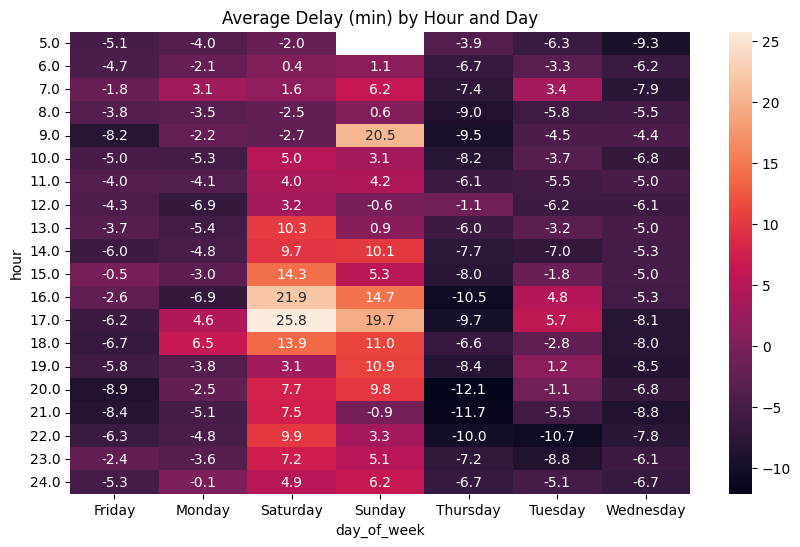

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".1f")
plt.title("Average Delay (min) by Hour and Day")
plt.show()